# Quantum Tunneling

## Action Plan
- We set up a simple system with two regions : one on the left of the barrier and one on the right |0> & |1>
- We introduce a small interaction between the two states
- Measure the probability

In [ ]:
pip install qiskit

In [ ]:
pip install qiskit-aer

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

## Create a simple system
- qc = QuantumCircuit(1) : starts in |0> by default
- The rx gate is a single-qubit parameterized rotation in quantum circuits that rotates the qubit state around the X-axis of the Bloch sphere by a specified angle
- This rotation will control the leakage more the angle more the leakage and smaller the angle smaller the leakage


In [ ]:
def run_circuit(angle, shots=10000):
    qc = QuantumCircuit(1)
   
    qc.rx(angle, 0)
    
    qc.measure_all()
    
    sim = AerSimulator()
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    
    p0 = counts.get('0', 0) / shots
    p1 = counts.get('1', 0) / shots
    
    return p0, p1

In [13]:
angle = 0.3  # small angle = small leakage

p0, p1 = run_circuit(angle)

print(f"P(|0⟩) = {p0}")
print(f"P(|1⟩) = {p1}")

P(|0⟩) = 0.9794
P(|1⟩) = 0.0206


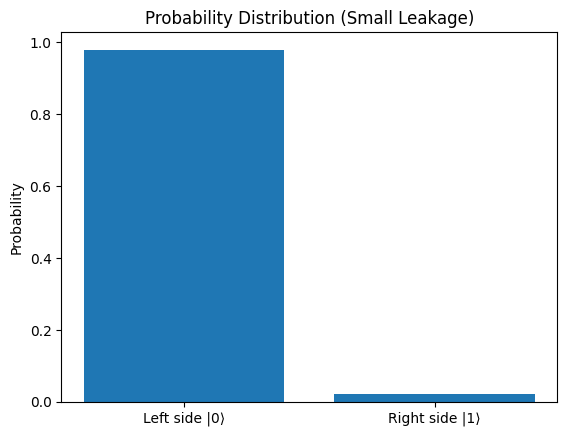

In [14]:
labels = ['Left side |0⟩', 'Right side |1⟩']
values = [p0, p1]

plt.figure()
plt.bar(labels, values)
plt.title("Probability Distribution (Small Leakage)")
plt.ylabel("Probability")
plt.show()

The small probability for measuring |1> is the non-zero probability leak

## Understanding barrier thickness and how it impacts leakage
- Thinner barrier (Large angle) more leakage
- Thicker barrier (Small angle) less leakage

In [9]:
angles = np.linspace(0, np.pi/2, 20)

p0_list = []
p1_list = []

for a in angles:
    p0, p1 = run_circuit(a)
    p0_list.append(p0)
    p1_list.append(p1)

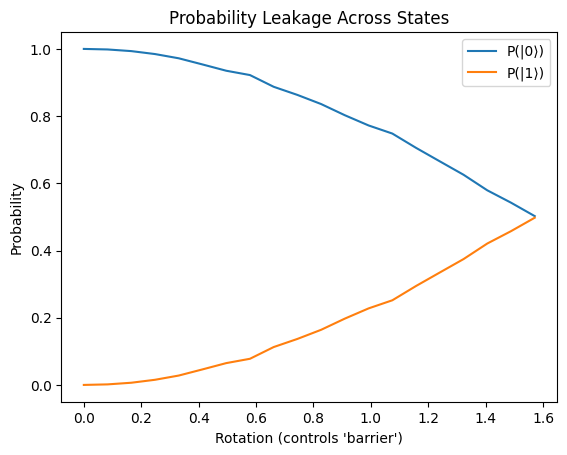

In [10]:
plt.figure()
plt.plot(angles, p0_list, label='P(|0⟩)')
plt.plot(angles, p1_list, label='P(|1⟩)')

plt.xlabel("Rotation (controls 'barrier')")
plt.ylabel("Probability")
plt.title("Probability Leakage Across States")
plt.legend()
plt.show()

## Observation 
When we introduced an interaction between our two states, we noticed a small probability of the particle being on the other side.

This isn’t quantum tunneling in the literal sense, but it captures the same idea. A system that should stay confined ends up showing a non-zero probability elsewhere.

The “leakage” was controlled by how strong the interaction was—which in this case is set by the angle we rotated the qubit about the x-axis.
- angle ≈ 0 → barrier is thick → no leakage
- small angle → barrier is thin → slight leakage
- larger angle → barrier weak → more probability crosses